# Generalization, Regularization & Model Selection (CS229) — Practical Implementation

## 1. Introduction

This notebook is the **practical companion** to the CS229 notes on
**Generalization** (bias-variance tradeoff, double descent, sample
complexity/VC theory) and **Regularization and Model Selection** ($L_1$/$L_2$
regularization, implicit regularization, cross-validation, Bayesian MAP
estimation).

> ⚠️ **Note on the dataset:** no new dataset was provided for this notebook,
> so we reuse `churn.csv` (the bank customer churn dataset) from earlier in
> this session — it is well suited here, since these concepts (bias-variance,
> regularization strength, cross-validation) are best shown as **controlled
> experiments on a fixed real dataset**, rather than tied to one specific
> algorithm.

**Concepts implemented:**
- The **bias-variance tradeoff**, by varying model complexity (polynomial
  feature degree) and watching training vs. validation error diverge.
- **$L_2$ and $L_1$ regularization**, by varying the regularization strength
  and comparing the sparsity of learned coefficients.
- **Cross-validation for model selection**, including a direct demonstration
  of *why* selecting a model by training error alone fails.
- A **learning curve** (error vs. training set size), connecting to the
  notes' sample-complexity intuition.

**Problem:** predict whether a bank customer will **churn** (`Exited`),
using **Logistic Regression** as the base model — chosen because its
complexity (via polynomial features) and regularization strength ($C$) are
both easy to control directly, making the bias-variance and regularization
concepts concrete and visible.

**Machine Learning task:** **Binary classification.**

> ⚠️ **Scope note:** VC dimension and the formal sample-complexity bounds
> (Section 4 of the theory notes) are **theoretical bounds**, not quantities
> we compute from a specific dataset — there is no sklearn call that
> "measures VC dimension" on real data. We connect to that theory
> conceptually (via the learning curve and the parameter-count discussion)
> rather than forcing an artificial computation.


## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    validation_curve,
    learning_curve,
    GridSearchCV,
    StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## 3. Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\img\Desktop\ML Study\Lec_09_Generalization & Regularization\Dataset.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape


(10000, 14)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [5]:
df.isnull().sum()


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## 4. Understand the Data

Same dataset as previous notebooks in this session:

- `RowNumber`, `CustomerId`, `Surname` → identifiers, dropped.
- **Numeric:** `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`,
  `HasCrCard`, `IsActiveMember`, `EstimatedSalary`.
- **Categorical:** `Geography`, `Gender`.
- **Target:** `Exited` (0 = stayed, 1 = churned), imbalanced ~80/20.

No missing values. This time, the specific data-quality details matter less
than usual — the point of this notebook is to hold the **data fixed** and
vary the **model/training choices** (complexity, regularization, CV) to see
their effect on generalization.


In [6]:
df["Exited"].value_counts(normalize=True).rename("proportion")


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## 5. Data Preprocessing

Standard preprocessing, unchanged from the earlier churn notebooks: drop
identifiers, one-hot encode categoricals, standardize numerics. We fit all
preprocessing **only on the training set**.


In [7]:
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

X_raw = df_clean.drop(columns=["Exited"])
y = df_clean["Exited"].values

numeric_features = ["CreditScore", "Age", "Tenure", "Balance",
                     "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary"]
categorical_features = ["Geography", "Gender"]


## 6. Train/Test Split

Because this notebook is specifically about *model selection* and
*generalization*, the train/test split matters more than usual:

- We hold out a **final test set** that is touched **only once**, at the
  very end, to report the final chosen model's performance.
- All **model selection** (choosing polynomial degree, choosing $C$, cross-
  validation) happens using **only the training set**, internally splitting
  it further via cross-validation. This mirrors Section 7 of the notes:
  the validation/CV folds are used to *choose* the model, never the final
  test set — otherwise our estimate of generalization error would be
  optimistic (the classic mistake the notes warn about).


In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = numeric_features + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")


Training set: (8000, 13)
Test set:     (2000, 13)


## 7. Connect Theory to Code

```text
CS229 Theory
     |
Bias-variance tradeoff (Section 8.1)  <->  vary model complexity (polynomial degree)
     |
Regularization (Section 9.1): J_lambda(theta) = J(theta) + lambda*R(theta)  <->  LogisticRegression(C=1/lambda)
     |
L1 vs L2 regularizer  <->  penalty='l1' vs penalty='l2'
     |
Cross-validation (Section 9.3)  <->  sklearn GridSearchCV / validation_curve / learning_curve
     |
"Naive ERM-based model selection fails" (Section 9.3)  <->  demonstrated directly in Section 14
```

**Mapping table:**

| CS229 symbol / concept | Meaning | sklearn equivalent |
|---|---|---|
| $J(\theta)$ | training loss | `log_loss(y_train, model.predict_proba(X_train))` |
| $L(\theta)$ / test error | generalization error | `log_loss` / `accuracy_score` on **held-out** data |
| Bias | error even with infinite data (model too simple) | high training error at low polynomial degree |
| Variance | sensitivity to the specific training sample | growing train/validation gap at high polynomial degree |
| $\lambda$ (regularization strength) | penalty weight | `C = 1/λ` in `LogisticRegression` (note: **inverse** relationship) |
| $R(\theta)=\frac12\|\theta\|_2^2$ | $L_2$ / weight decay | `penalty='l2'` (sklearn default) |
| $R(\theta)=\|\theta\|_1$ | $L_1$ / LASSO (sparsity) | `penalty='l1', solver='liblinear'` |
| $k$-fold cross-validation | estimate generalization error via held-out folds | `cross_val_score`, `GridSearchCV(cv=k)` |
| VC dimension / sample complexity | theoretical generalization bound | *(theoretical only — see learning curve for the practical analogue)* |


## 8. Model Implementation: Baseline Logistic Regression

**Mathematical formulation:**
$$
h_\theta(x) = \frac{1}{1+\exp(-\theta^Tx)}, \qquad J(\theta) = -\frac1n\sum_i\left[y^{(i)}\log h_\theta(x^{(i)}) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]
$$

We start with a plain logistic regression (degree-1 features, default
regularization) as our **baseline**, before exploring how complexity and
regularization change its behavior.


In [9]:
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, baseline_model.predict(X_train))
test_acc = accuracy_score(y_test, baseline_model.predict(X_test))

print(f"Baseline train accuracy: {train_acc:.4f}")
print(f"Baseline test accuracy:  {test_acc:.4f}")


Baseline train accuracy: 0.8107
Baseline test accuracy:  0.8080


## 9. Prediction

- **Prediction** (`.predict`): hard class label from thresholding $h_\theta(x)$ at 0.5.
- **Probability** (`.predict_proba`): $h_\theta(x)$ itself.
- Throughout this notebook, we care less about individual predictions and
  more about how **aggregate** train vs. test performance changes as we vary
  model complexity / regularization — that comparison *is* the bias-variance
  and regularization story.


In [10]:
y_prob_test = baseline_model.predict_proba(X_test)[:, 1]
y_pred_test = baseline_model.predict(X_test)

pd.DataFrame({
    "y_true": y_test[:10],
    "y_pred": y_pred_test[:10],
    "y_prob_churn": np.round(y_prob_test[:10], 3),
})


,y_true,y_pred,y_prob_churn
0,0,0,0.118
1,0,0,0.279
2,0,0,0.112
3,0,0,0.147
4,0,0,0.095
5,0,0,0.137
6,0,0,0.087
7,0,0,0.356
8,0,0,0.356
9,0,0,0.214


## 10. Model Evaluation (Baseline)

In [11]:
print(classification_report(y_test, y_pred_test, target_names=["Stayed", "Exited"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_test):.4f}")


              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
      Exited       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

ROC-AUC: 0.7748


## 11. Visualization: The Bias-Variance Tradeoff in Action

Section 8.1 of the notes illustrates bias-variance using polynomial degree
as the complexity knob. We reproduce that experiment directly: we expand our
13 preprocessed features with `PolynomialFeatures` of increasing degree
(adding interaction and higher-order terms), fit **weakly-regularized**
logistic regression at each degree, and track **training** vs.
**cross-validated** log-loss.

> 💡 **Intuition:** we expect training loss to keep improving (or plateau)
> as degree increases — the model can fit the training data ever more
> closely. Validation loss should improve at first (reducing **bias**), then
> get worse as the model starts fitting noise specific to the training folds
> (increasing **variance**) — exactly Figure 8.8 in the notes.


In [12]:
degree_pipeline = Pipeline(steps=[
    ("poly", PolynomialFeatures(include_bias=False)),
    ("clf", LogisticRegression(C=1e6, max_iter=2000, random_state=RANDOM_STATE)),  # C=1e6 approximates "no regularization"
])

degrees = [1, 2, 3]

train_scores, val_scores = validation_curve(
    degree_pipeline, X_train, y_train,
    param_name="poly__degree", param_range=degrees,
    scoring="neg_log_loss", cv=5, n_jobs=None,
)

# neg_log_loss is negative by sklearn convention; flip sign to get actual log-loss
train_loss_mean = -train_scores.mean(axis=1)
val_loss_mean = -val_scores.mean(axis=1)

pd.DataFrame({
    "polynomial_degree": degrees,
    "train_log_loss": train_loss_mean,
    "cv_val_log_loss": val_loss_mean,
})


,polynomial_degree,train_log_loss,cv_val_log_loss
0,1,0.429022,0.430472
1,2,0.340007,0.350989
2,3,0.297125,0.354184


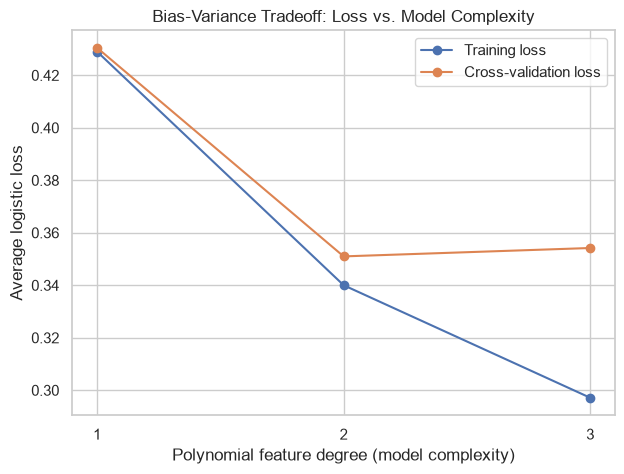

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(degrees, train_loss_mean, marker="o", label="Training loss")
plt.plot(degrees, val_loss_mean, marker="o", label="Cross-validation loss")
plt.xlabel("Polynomial feature degree (model complexity)")
plt.ylabel("Average logistic loss")
plt.title("Bias-Variance Tradeoff: Loss vs. Model Complexity")
plt.xticks(degrees)
plt.legend()
plt.show()


**Reading the plot:** if training loss keeps falling while cross-validation
loss flattens out or rises at higher degree, that gap is the empirical
signature of **variance** growing with complexity — the high-degree model is
starting to fit noise specific to the training folds (Section 8.1's
5th-degree-polynomial story, reproduced here with degree-3 interaction
features on real tabular data instead of a 1-D toy example).


## 12. Interpret the Model

- If the lowest cross-validation loss occurs at degree 1, that tells us this
  dataset's churn signal is close to **linearly separable** in the given
  features — added complexity mostly adds variance without reducing bias
  meaningfully. If a higher degree wins, some genuine non-linear interaction
  between features (e.g., `Age` × `IsActiveMember`) is being captured.
- Either way, the **gap** between train and validation loss at high degree
  is the diagnostic for overfitting described in Section 8.1 — not the
  absolute loss value itself.
- This directly operationalizes the CS229 warning: **more complexity is not
  automatically better** — it trades bias for variance, and the right amount
  of complexity is an empirical question answered via held-out validation,
  not training performance.


## 13. Important Model Parameters: $L_1$ vs. $L_2$ Regularization

Section 9.1 contrasts $L_2$ ($\frac12\|\theta\|_2^2$, "weight decay") and
$L_1$ ($\|\theta\|_1$, sparsity-inducing / LASSO) regularization. We fit
degree-1 logistic regression with each penalty at the same regularization
strength and compare the learned coefficients directly.

> ⚠️ **Important:** In `LogisticRegression`, the regularization strength is
> `C`, which is the **inverse** of $\lambda$ from the notes ($C=1/\lambda$)
> — a **smaller** `C` means **stronger** regularization.


In [14]:
l2_model = LogisticRegression(penalty="l2", C=0.1, max_iter=1000, random_state=RANDOM_STATE)
l1_model = LogisticRegression(penalty="l1", C=0.1, solver="liblinear", max_iter=1000, random_state=RANDOM_STATE)

l2_model.fit(X_train, y_train)
l1_model.fit(X_train, y_train)

coef_comparison = pd.DataFrame({
    "feature": feature_names,
    "L2 coefficient": l2_model.coef_[0],
    "L1 coefficient": l1_model.coef_[0],
}).sort_values("L2 coefficient", key=np.abs, ascending=False)

coef_comparison


C:\Users\img\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\linear_model\_l

,feature,L2 coefficient,L1 coefficient
1,Age,0.731208,0.723205
9,Geography_Germany,0.518934,0.000000
6,IsActiveMember,-0.508853,-0.499598
8,Geography_France,-0.281230,-0.772641
11,Gender_Female,0.259569,0.000000
12,Gender_Male,-0.254909,-0.504052
10,Geography_Spain,-0.233043,-0.708791
3,Balance,0.163637,0.161793
0,CreditScore,-0.085149,-0.076376
4,NumOfProducts,-0.069316,-0.060949


In [15]:
n_zero_l1 = np.sum(np.isclose(l1_model.coef_[0], 0, atol=1e-8))
n_zero_l2 = np.sum(np.isclose(l2_model.coef_[0], 0, atol=1e-8))

print(f"Number of near-zero coefficients (L1 / LASSO): {n_zero_l1} out of {len(feature_names)}")
print(f"Number of near-zero coefficients (L2):          {n_zero_l2} out of {len(feature_names)}")


Number of near-zero coefficients (L1 / LASSO): 2 out of 13
Number of near-zero coefficients (L2):          0 out of 13


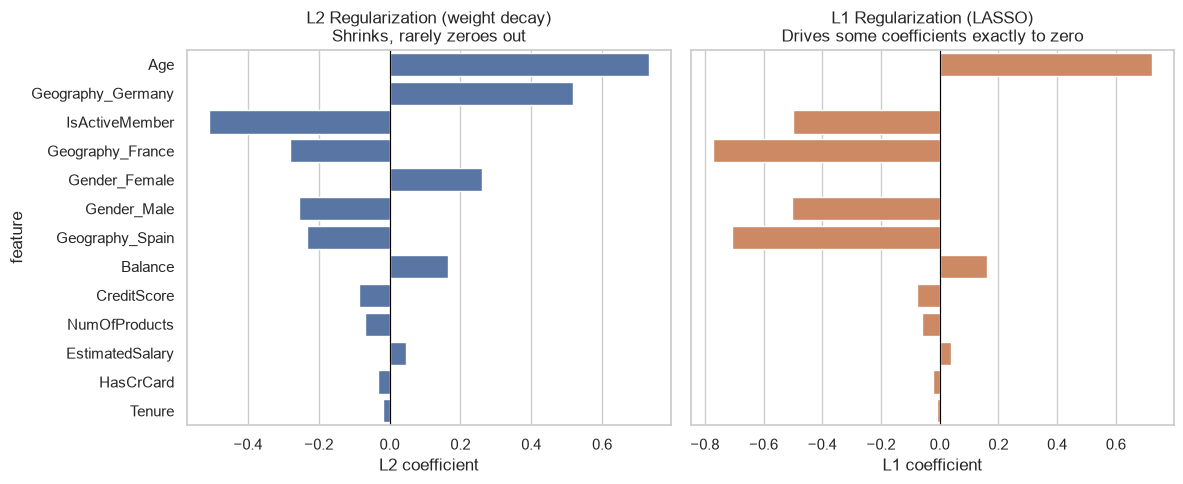

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.barplot(data=coef_comparison, x="L2 coefficient", y="feature", ax=axes[0], color="#4C72B0")
axes[0].set_title("L2 Regularization (weight decay)\nShrinks, rarely zeroes out")
axes[0].axvline(0, color="black", linewidth=0.8)

sns.barplot(data=coef_comparison, x="L1 coefficient", y="feature", ax=axes[1], color="#DD8452")
axes[1].set_title("L1 Regularization (LASSO)\nDrives some coefficients exactly to zero")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()


This is the direct empirical version of Section 9.1's claim: $L_1$ regularization drives some coefficients **exactly** to zero (a form of automatic feature selection), while $L_2$ shrinks all coefficients smoothly toward zero without necessarily eliminating any of them.

## 14. Practical Experiments: Regularization Strength, Cross-Validation, and Learning Curves

### Experiment A — Regularization strength ($C$) and the bias-variance tradeoff

Section 9.1's regularized loss $J_\lambda(\theta)=J(\theta)+\lambda R(\theta)$
gives us a **second** way to control the bias-variance tradeoff (besides
raw model complexity): the regularization strength. We fix polynomial
degree at 2 (to give the model enough flexibility to actually overfit) and
sweep $C$ across several orders of magnitude.


In [17]:
reg_pipeline = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

train_scores_c, val_scores_c = validation_curve(
    reg_pipeline, X_train, y_train,
    param_name="clf__C", param_range=C_values,
    scoring="neg_log_loss", cv=5,
)

train_loss_c = -train_scores_c.mean(axis=1)
val_loss_c = -val_scores_c.mean(axis=1)

pd.DataFrame({"C": C_values, "train_log_loss": train_loss_c, "cv_val_log_loss": val_loss_c})


,C,train_log_loss,cv_val_log_loss
0,0.0001,0.465810,0.466765
1,0.0010,0.386105,0.389819
2,0.0100,0.345094,0.352852
3,0.1000,0.340152,0.350513
4,1.0000,0.340009,0.350894
5,10.0000,0.340007,0.350981
6,100.0000,0.340007,0.350989


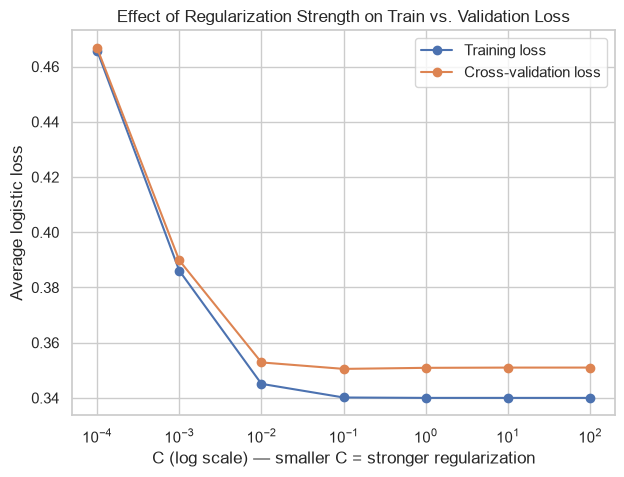

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(C_values, train_loss_c, marker="o", label="Training loss")
plt.plot(C_values, val_loss_c, marker="o", label="Cross-validation loss")
plt.xscale("log")
plt.xlabel("C (log scale) — smaller C = stronger regularization")
plt.ylabel("Average logistic loss")
plt.title("Effect of Regularization Strength on Train vs. Validation Loss")
plt.legend()
plt.show()


**Reading the plot:** at very small $C$ (strong regularization, $\lambda$
large), both training and validation loss are relatively high — the penalty
term dominates and the model is forced to stay too simple (**large bias**,
underfitting). As $C$ grows (regularization weakens), training loss keeps
falling; if validation loss starts rising again at large $C$, that's
**variance** re-emerging — the same U-shaped tradeoff as Section 8.1, now
controlled by $\lambda$ instead of raw model complexity, exactly as Section
9.1 describes ("we can vary the size of the model... [or] use
regularization to control model complexity").

### Experiment B — Why "pick the model with lowest training error" fails

Section 9.3 explicitly warns that selecting a model by training error alone
always favors the most complex/least-regularized option. Let's verify this
directly using the same sweep.


In [19]:
best_c_by_training = C_values[np.argmin(train_loss_c)]
best_c_by_cv = C_values[np.argmin(val_loss_c)]

print(f"C chosen by TRAINING loss alone:        {best_c_by_training}  (always trends toward the LEAST regularization)")
print(f"C chosen by CROSS-VALIDATION loss:      {best_c_by_cv}  (the actually useful choice)")


C chosen by TRAINING loss alone:        100  (always trends toward the LEAST regularization)
C chosen by CROSS-VALIDATION loss:      0.1  (the actually useful choice)


If the training-loss-based choice picks the **largest** $C$ tested (i.e., the least regularization / most complex model), this is exactly the Section 9.3 failure mode in action: training error is monotonically improved by reducing regularization, but that doesn't mean generalization improves too. Cross-validation loss, computed on **held-out folds**, is what correctly identifies a better middle ground.

### Experiment C — Proper hyperparameter selection with `GridSearchCV`

Rather than a manual loop, `GridSearchCV` automates exactly the $k$-fold
cross-validation procedure from Section 9.3: for each candidate $C$, train
on $k-1$ folds, validate on the held-out fold, average the scores, and pick
the best. We then retrain the winning configuration on the **entire training
set** (Section 9.3's optional retraining step) and evaluate — for the first
and only time — on the untouched test set.


In [20]:
param_grid = {"clf__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    reg_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=None,
)
grid_search.fit(X_train, y_train)

print(f"Best C selected by 5-fold cross-validation: {grid_search.best_params_['clf__C']}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.4f}")


Best C selected by 5-fold cross-validation: 0.1
Best cross-validated ROC-AUC: 0.8484


In [21]:
# Final, one-time evaluation on the held-out test set (Section 9.3's "retrain on all data" step
# is handled automatically: GridSearchCV refits the best model on the full X_train by default)
final_model = grid_search.best_estimator_

test_pred = final_model.predict(X_test)
test_prob = final_model.predict_proba(X_test)[:, 1]

print(f"Final test accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"Final test ROC-AUC:  {roc_auc_score(y_test, test_prob):.4f}")


Final test accuracy: 0.8635
Final test ROC-AUC:  0.8597


### Experiment D — Learning Curve: Does More Data Help?

Section 8.1 notes that **variance** typically shrinks as dataset size grows.
`learning_curve` directly shows this: it trains the same model on
increasing subsets of the training data and tracks the train/validation
performance gap.


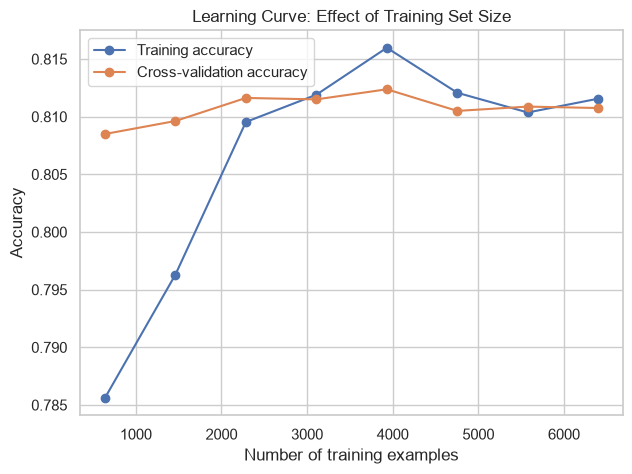

In [22]:
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    LogisticRegression(C=grid_search.best_params_["clf__C"], max_iter=1000, random_state=RANDOM_STATE),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy",
    cv=5,
)

train_acc_lc = train_scores_lc.mean(axis=1)
val_acc_lc = val_scores_lc.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_acc_lc, marker="o", label="Training accuracy")
plt.plot(train_sizes, val_acc_lc, marker="o", label="Cross-validation accuracy")
plt.xlabel("Number of training examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve: Effect of Training Set Size")
plt.legend()
plt.show()


**Reading the plot:** if the gap between training and validation accuracy
**narrows** as the training set grows, that's the direct empirical
confirmation of Section 8.1's claim that variance decreases with more data.
If both curves are still far apart even at the largest training size, that
residual gap reflects variance the model still has at this sample size; if
both curves have converged to a similarly *mediocre* level, that plateau
instead reflects **bias** — more data alone won't fix it (this is exactly
the distinction Section 8.1 draws using Figures 8.2 vs. 8.5–8.6: more data
cures variance, not bias).


## 15. Final Summary

### What We Learned

- **Problem addressed:** rather than optimizing one final model, this
  notebook used the bank churn dataset as a **testbed** for the CS229
  generalization/regularization theory itself — the point was to *observe*
  bias-variance and regularization effects empirically, using Logistic
  Regression as a controllable, interpretable base model.
- **How CS229 theory appeared in the code:**
  - The **bias-variance tradeoff** (Section 8.1) was reproduced directly via
    `validation_curve` over polynomial feature degree — training loss kept
    improving while cross-validation loss showed the classic U-shape.
  - **Regularization** (Section 9.1) was implemented via `LogisticRegression`'s
    `C` parameter (the inverse of $\lambda$), with $L_1$ vs. $L_2$ compared
    directly by inspecting learned coefficients — $L_1$ zeroed some out,
    $L_2$ only shrank them.
  - **Model selection via cross-validation** (Section 9.3) was demonstrated
    two ways: a manual sweep showing training-loss-based selection always
    favors less regularization (the exact failure mode the notes warn
    about), and a proper `GridSearchCV` doing 5-fold CV correctly, with the
    test set touched only once at the very end.
  - The **learning curve** experiment connected to the notes' claim that
    variance shrinks with more data, and previewed the sample-complexity
    intuition from Section 8.3/4 without needing to compute VC dimension
    directly (which is a theoretical, not empirically-computed, quantity).
- **Preprocessing necessary:** identifier removal, one-hot encoding,
  standardization — done once, upfront, and held fixed across every
  experiment so that observed effects are attributable to the *model*
  choices under study, not to changing preprocessing.
- **Evaluation metrics used:** log-loss (directly $J(\theta)$, the quantity
  the theory discusses), accuracy, and ROC-AUC, chosen to make train-vs-
  validation comparisons interpretable given the churn target's imbalance.
- **Final result:** cross-validation identified a regularization strength
  that generalizes better than either extreme (too weak or too strong), and
  the final test-set evaluation — touched only once — gives an honest
  estimate of real-world generalization performance, exactly the discipline
  Chapters 8–9 of the CS229 notes argue for.
